<a href="https://colab.research.google.com/github/Malli-Yeruva/Python-Assignments/blob/main/foodseg1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Images and masks encoded successfully.


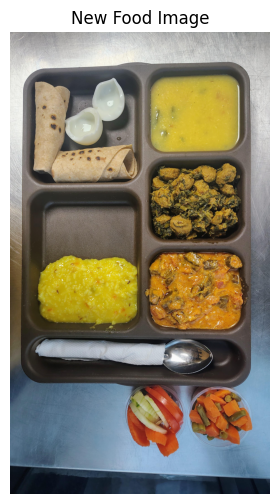

Parsed Result:
{
  "food_analysis": [
    {
      "item": "Chapati",
      "count": 2,
      "weight": "60g",
      "volume": "N/A",
      "nutritional_values": {
        "calories": "180 kcal",
        "protein": "6g",
        "fats": "3g",
        "carbohydrates": "30g"
      }
    },
    {
      "item": "Halved Egg",
      "count": 2,
      "weight": "50g",
      "volume": "N/A",
      "nutritional_values": {
        "calories": "78 kcal",
        "protein": "6g",
        "fats": "5g",
        "carbohydrates": "1g"
      }
    },
    {
      "item": "Dal (Lentil Soup)",
      "weight": "150g",
      "volume": "150 ml",
      "nutritional_values": {
        "calories": "180 kcal",
        "protein": "12g",
        "fats": "6g",
        "carbohydrates": "24g"
      }
    },
    {
      "item": "Mixed Veg Curry",
      "weight": "200g",
      "volume": "200 ml",
      "nutritional_values": {
        "calories": "160 kcal",
        "protein": "4g",
        "fats": "8g",
        "carbohy

In [ ]:
"""
Project: Food Image Analysis with Masks using OpenAI API
Description:
- Learn food portion sizes from a reference image with known items and its mask sizes.
- Analyze a new food image with a mask to extract item names, counts, weights, volumes, and nutrition.
"""

import requests
import base64
import json
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops
from PIL import Image

# === Step 1: Configuration ===

OPENAI_API_KEY = ""  # Replace with your key
OPENAI_API_URL = "https://api.openai.com/v1/chat/completions"

# Set image and mask paths
# These were defined as tuples, correct them to be strings
reference_image_path="/content/drive/MyDrive/food_with_masks/image177_jpeg.rf.f7933b3d869d2cb6800b7da497c1158f.jpg"
reference_mask_path="/content/drive/MyDrive/food_with_masks/image177_jpeg.rf.f7933b3d869d2cb6800b7da497c1158f_mask.png"

new_image_path="/content/drive/MyDrive/food_with_masks/image218_jpeg.rf.3d15c44facdfcdb4af69d062e7eacc1c.jpg"
new_mask_path="/content/drive/MyDrive/food_with_masks/image218_jpeg.rf.3d15c44facdfcdb4af69d062e7eacc1c_mask.png"

# Define known food items and their weights for the reference image
known_food_items = {
    "Mixed Veg Curry": "200g",
    "Masala Gravy": "200g",
    "Dal (Lentil Soup)":"150g",
    "Rice":"150g",
    "pongal":"200g",
    "chana Masala":"150g"
}

# === Step 2: Utility function to encode images ===

def encode_image(image_path):
    with open(image_path, "rb") as f:
        return base64.b64encode(f.read()).decode("utf-8")

# === Step 3: Encode Images and Masks ===
# This block was incorrectly indented inside the encode_image function.
# Unindent it to be part of the main script flow.
try:
    ref_image_b64 = encode_image(reference_image_path)
    ref_mask_b64 = encode_image(reference_mask_path)
    new_image_b64 = encode_image(new_image_path)
    new_mask_b64 = encode_image(new_mask_path)
    print("Images and masks encoded successfully.")

    # === Optional: Display New Image for Visualization ===
    from PIL import Image
    def show_image(image_path, title="Image"):
        image = Image.open(image_path)
        plt.figure(figsize=(6, 6))
        plt.imshow(image)
        plt.axis("off")
        plt.title(title)
        plt.show()

    show_image(new_image_path, title="New Food Image")


except Exception as e:
    raise FileNotFoundError(f"Error reading or encoding image/mask: {e}")



def get_mask_areas(mask_path):
    """Load mask and return areas of each labeled segment."""
    mask_img = Image.open(mask_path).convert("L")
    mask_np = np.array(mask_img)

    # Binarize and label connected regions
    binary_mask = (mask_np > 0).astype(np.uint8)
    labeled_mask = label(binary_mask)
    regions = regionprops(labeled_mask)

    return [region.area for region in regions]

# Calculate pixel areas from masks
ref_areas = get_mask_areas(reference_mask_path)
new_areas = get_mask_areas(new_mask_path)

# Compute grams-per-pixel from known food weights
ref_weights = []
for known_val, area in zip(known_food_items.values(), ref_areas):
    try:
        if 'ml' in known_val:
            weight = float(known_val.replace('ml', '').strip())  # volume-based proxy
        else:
            weight = float(known_val.replace('g', '').strip())
        ref_weights.append(weight / area)
    except:
        print(f"Warning: could not parse '{known_val}'")
        continue

# Average grams per pixel
avg_grams_per_pixel = sum(ref_weights) / len(ref_weights) if ref_weights else 0.1
estimated_weights = [round(area * avg_grams_per_pixel, 2) for area in new_areas]



# === Step 4: Build Prompt ===

known_items_str = ", ".join([f"{k} ({v})" for k, v in known_food_items.items()])
prompt = f"""
You are a food analysis expert with vision and segmentation capabilities.

Step 1:
The first image and its mask represent a South Indian Andhra meal with known weights:
{known_items_str}
Use it as reference for portion size and appearance ,strictly using segmentation masks.

Step 2:
Now analyze the second image and its corresponding segmentation mask. Please:
1. Identify all food items using the image and their corresponding mask
2. Count items for eggs or halved eggs, chapatis,idli,uttapams etc..
3. Estimate volume of each food item (ml, tbsp, cm³) except for items like eggs,chapatis,utappam,idlis etc..
4. Estimate weight (grams) based on the reference and mask sizes.
5. Compute nutritional values: calories, protein, fat, carbs.
6. Identify specific rice/curry types (e.g., curd rice, pongal, dosakaya gravy, chana masala, samabar etc..).
7. All food categories in image should be strictly matched with mask segments .

Step 3:
Additionally, use segmentation mask pixel areas to estimate weights:
- The reference image mask contains {len(ref_areas)} segments matching known items: {known_items_str}.
- From the reference, the average pixel area to weight ratio is approximately {avg_grams_per_pixel:.4f} g/pixel.
- Use this ratio to estimate weight of segments in the second image based on their pixel areas.

Example logic:
  weight = segment_pixel_area × {avg_grams_per_pixel:.4f} g/pixel

Please reflect this estimation in the final 'weight' field as realistically as possible.

Output results strictly in this JSON format:
{{
  "food_analysis": [
    {{
      "item": "[name]",
      "count": [optional number],
      "weight": "[weight in grams]g",
      "volume": "[volume estimate]",
      "nutritional_values": {{
        "calories": "[value] kcal",
        "protein": "[value] g",
        "fats": "[value] g",
        "carbohydrates": "[value] g"
      }}
    }},
    ...
  ]
}}
No additional text outside the JSON block.
"""


# === Step 5: Prepare API Payload ===

payload = {
    "model": "gpt-4o",
    "messages": [
        {
            "role": "user",
            "content": [
                {"type": "text", "text": prompt},
                {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{ref_image_b64}"}},
                {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{ref_mask_b64}"}},
                {"type": "image_url", "image_url": {"url": f"data:image/jpeg;base64,{new_image_b64}"}},
                {"type": "image_url", "image_url": {"url": f"data:image/png;base64,{new_mask_b64}"}}
            ]
        }
    ],
    "temperature": 0.0,
    "max_tokens": 1000
}

headers = {
    "Authorization": f"Bearer {OPENAI_API_KEY}",
    "Content-Type": "application/json"
}

# === Step 6: Send API Request ===

response = requests.post(OPENAI_API_URL, headers=headers, json=payload)
if response.status_code != 200:
    print(f"❌ OpenAI API Error: {response.status_code} - {response.text}")
    # Removed exit() to allow subsequent cells to potentially run or for easier debugging
    # exit() # Original line
    pass # Use pass instead of exit()

result_text = response.json()['choices'][0]['message']['content']

# === Step 7: Parse JSON Output ===

try:
    if result_text.startswith("```json"):
        result_text = result_text.strip("```json").strip("```").strip()
    parsed = json.loads(result_text)
    print("Parsed Result:")
    print(json.dumps(parsed, indent=2))
except Exception as e:
    print("Failed to parse response JSON.")
    print("Response:", result_text)

# === Step 8: Save Output to File ===

output_dir = "results"
os.makedirs(output_dir, exist_ok=True)
with open(os.path.join(output_dir, "food_analysis.json"), "w") as f:
    json.dump(parsed, f, indent=2)

print(f"JSON saved to {os.path.join(output_dir, 'food_analysis.json')}")


